# 03 - Avaliação dos Modelos e Interpretação dos Resultados

Avaliação dos três modelos treinados (notebook 02) no conjunto de **teste**
(dados nunca vistos durante o treino), seguida da interpretação de quais
variáveis mais influenciam a previsão de qualidade e das implicações práticas
para o processo produtivo.

In [1]:
import sys
sys.path.insert(0, "../src")
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (ConfusionMatrixDisplay, PrecisionRecallDisplay,
                              RocCurveDisplay, accuracy_score, average_precision_score,
                              confusion_matrix, f1_score, precision_score, recall_score,
                              roc_auc_score)

from data_loader import load_dataset
from modeling import get_models
from preprocessing import split_data

sns.set_theme(style="whitegrid")
RESULTS = "../results"

df = load_dataset()
X_train, X_test, y_train, y_test = split_data(df)

models = get_models(y_train)
for name, pipe in models.items():
    pipe.fit(X_train, y_train)
print("Modelos treinados:", list(models.keys()))

Modelos treinados: ['logistic_regression', 'random_forest', 'xgboost']


## Escolha das métricas

Como visto na EDA, o target é desbalanceado (~80/20). Um classificador trivial
que sempre previsse "Baixa/Média Qualidade" já atingiria ~80% de acurácia sem
nenhum valor preditivo real. Por isso a avaliação prioriza:

- **Precisão e Recall da classe "Alta Qualidade"** - respectivamente, "das
  vezes que o modelo aposta em alta qualidade, quantas acertou" e "de todos os
  vinhos realmente de alta qualidade, quantos o modelo encontrou".
- **F1-score** - equilíbrio entre as duas.
- **ROC-AUC** - separabilidade geral entre as classes.
- **PR-AUC (average precision)** - mais informativa que ROC-AUC quando a
  classe positiva é minoritária, pois não é inflada pelos muitos verdadeiros
  negativos.
- Acurácia é reportada apenas como referência complementar, não como métrica
  de decisão.

In [2]:
rows = []
proba_by_model = {}
for name, pipe in models.items():
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]
    proba_by_model[name] = y_proba
    rows.append({
        "modelo": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba),
        "pr_auc": average_precision_score(y_test, y_proba),
    })

metrics_df = pd.DataFrame(rows).set_index("modelo").round(3).sort_values("f1", ascending=False)
metrics_df.to_csv(f"{RESULTS}/metrics_comparison.csv")
metrics_df

,accuracy,precision,recall,f1,roc_auc,pr_auc
modelo,,,,,,
random_forest,0.836,0.554,0.688,0.614,0.875,0.633
xgboost,0.806,0.493,0.688,0.574,0.859,0.591
logistic_regression,0.728,0.392,0.782,0.522,0.815,0.466


## Leitura dos resultados no conjunto de teste

| Modelo | Accuracy | Precision | Recall | F1 | ROC-AUC | PR-AUC |
|---|---|---|---|---|---|---|
| Random Forest | 0,836 | 0,554 | 0,688 | **0,614** | **0,875** | **0,633** |
| XGBoost | 0,806 | 0,493 | 0,688 | 0,574 | 0,859 | 0,591 |
| Regressão Logística | 0,728 | 0,392 | **0,782** | 0,522 | 0,815 | 0,466 |

- **Random Forest** vence em quase todas as métricas (F1, ROC-AUC, PR-AUC,
  precisão e acurácia) - é o modelo recomendado como escolha principal.
- **Regressão Logística** tem o maior recall (0,78): identifica mais vinhos
  de alta qualidade de fato, mas ao custo de muito mais falsos positivos
  (precisão de apenas 0,39 - menos de 4 em cada 10 vinhos que ela aponta como
  "alta qualidade" realmente são).
- **XGBoost** fica no meio termo, sem superar o Random Forest em nenhuma
  métrica nesta configuração de hiperparâmetros.

**Implicação de negócio**: a escolha entre Random Forest e Regressão Logística
depende do custo relativo do erro. Se o objetivo é **triagem ampla** (não
deixar passar nenhum lote potencialmente premium, aceitando revisar manualmente
alguns falsos positivos), a Regressão Logística's maior recall pode ser
preferível. Se o objetivo é **confiabilidade do rótulo** (por exemplo, decidir
sozinho, sem revisão humana, quais lotes recebem selo de alta qualidade), o
Random Forest é a escolha mais segura por sua precisão muito superior.

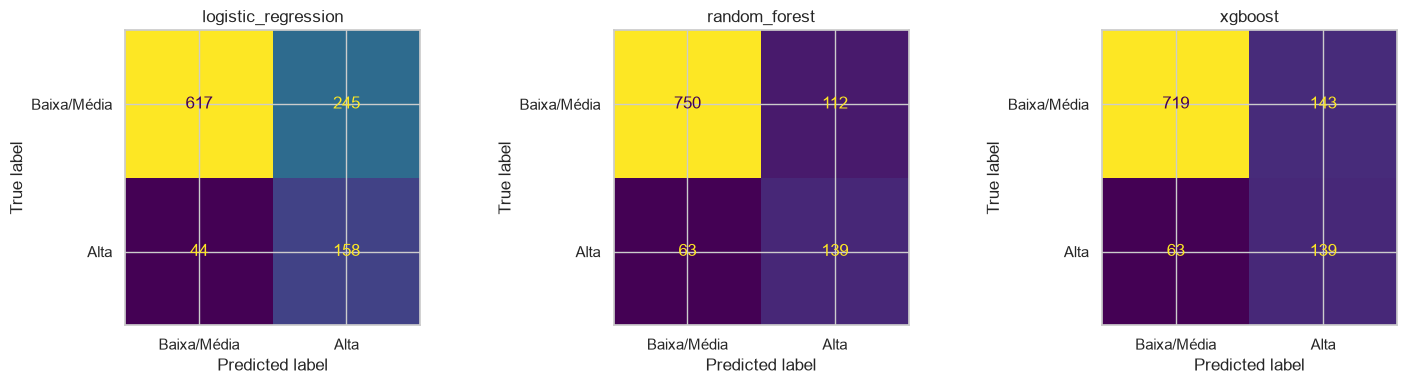

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, pipe) in zip(axes, models.items()):
    y_pred = pipe.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=["Baixa/Média", "Alta"]).plot(ax=ax, colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.savefig(f"{RESULTS}/06_confusion_matrices.png", dpi=150)
plt.show()

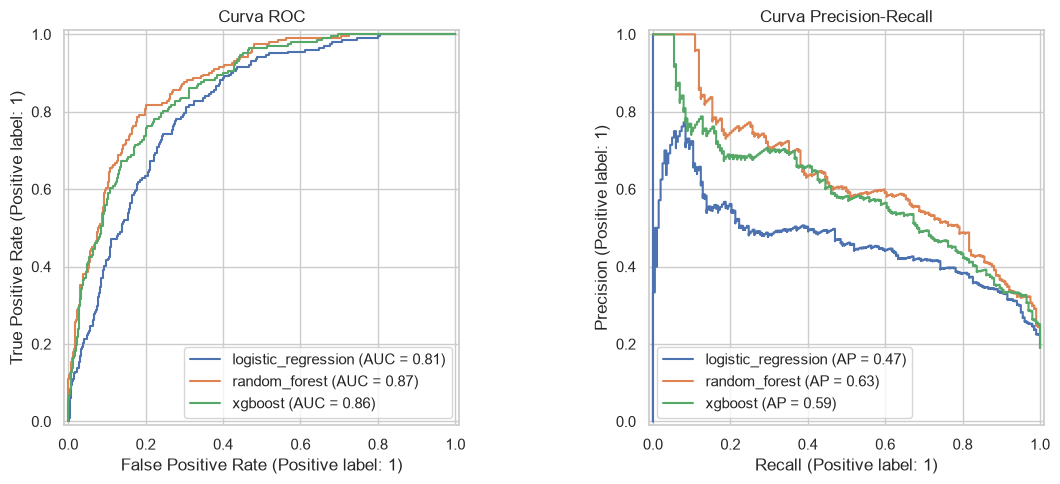

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for name, pipe in models.items():
    RocCurveDisplay.from_estimator(pipe, X_test, y_test, ax=axes[0], name=name)
    PrecisionRecallDisplay.from_estimator(pipe, X_test, y_test, ax=axes[1], name=name)
axes[0].set_title("Curva ROC")
axes[1].set_title("Curva Precision-Recall")
plt.tight_layout()
plt.savefig(f"{RESULTS}/07_roc_pr_curves.png", dpi=150)
plt.show()

## Interpretação: quais variáveis mais influenciam a qualidade

Para os modelos de árvore (Random Forest, XGBoost) foi extraída a
importância de cada variável (`feature_importances_`); para a Regressão
Logística, os coeficientes padronizados (comparáveis entre si porque as
variáveis foram escalonadas antes do treino).

In [5]:
feat_names = models["random_forest"].named_steps["preprocessor"].get_feature_names_out()
feat_names = [f.split("__")[-1] for f in feat_names]

rf_imp = pd.Series(models["random_forest"].named_steps["classifier"].feature_importances_, index=feat_names)
xgb_imp = pd.Series(models["xgboost"].named_steps["classifier"].feature_importances_, index=feat_names)
lr_coef = pd.Series(models["logistic_regression"].named_steps["classifier"].coef_[0], index=feat_names)

importance_df = pd.DataFrame({
    "random_forest": rf_imp,
    "xgboost": xgb_imp,
    "logistic_regression_coef": lr_coef,
}).sort_values("random_forest", ascending=False)
importance_df.to_csv(f"{RESULTS}/feature_importance.csv")
importance_df

,random_forest,xgboost,logistic_regression_coef
alcohol,0.206841,0.343619,0.638597
density,0.118485,0.040587,-1.303324
chlorides,0.081488,0.044301,-0.224755
volatile_acidity,0.079831,0.083033,-0.609570
free_so2_ratio,0.072757,0.057717,0.391189
total_sulfur_dioxide,0.071915,0.054227,-0.060085
citric_acid,0.069934,0.050049,0.030691
sulphates,0.066455,0.059389,0.386377
residual_sugar,0.062051,0.047818,0.940038
pH,0.058972,0.057244,0.512617


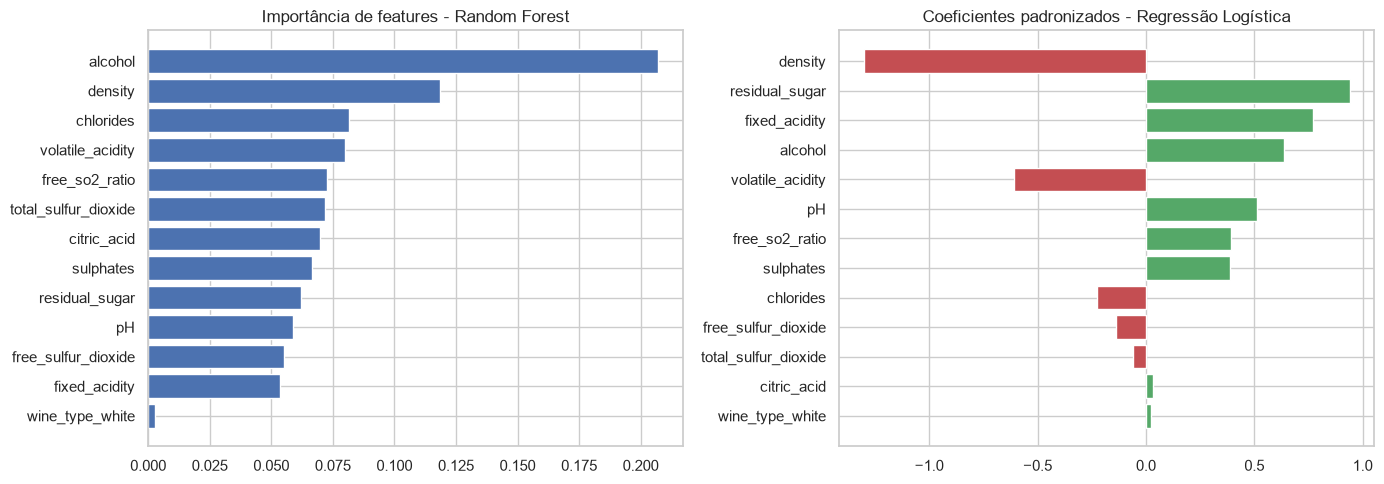

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_rf = importance_df["random_forest"].sort_values()
axes[0].barh(top_rf.index, top_rf.values, color="#4C72B0")
axes[0].set_title("Importância de features - Random Forest")

top_lr = lr_coef.reindex(lr_coef.abs().sort_values().index)
colors = ["#C44E52" if v < 0 else "#55A868" for v in top_lr.values]
axes[1].barh(top_lr.index, top_lr.values, color=colors)
axes[1].set_title("Coeficientes padronizados - Regressão Logística")

plt.tight_layout()
plt.savefig(f"{RESULTS}/08_feature_importance.png", dpi=150)
plt.show()

### Síntese da interpretação

- **Álcool é, de forma consistente, a variável mais importante** nos três
  modelos (importância de 0,21 no Random Forest e 0,34 no XGBoost - a maior
  isoladamente). Confirma o que já aparecia na correlação da EDA (+0,39):
  vinhos com maior teor alcoólico tendem a ser mais bem avaliados.
- **Density, chlorides e volatile_acidity** aparecem consistentemente entre as
  variáveis mais relevantes nos modelos de árvore, replicando o padrão visto
  na EDA.
- A **Regressão Logística diverge parcialmente** dos modelos de árvore: nela,
  `density` tem o maior coeficiente em módulo, e `residual_sugar` e
  `fixed_acidity` aparecem com peso alto e sinal positivo - o que contradiz a
  correlação marginal quase nula dessas duas variáveis vista na EDA. Isso é um
  efeito clássico de **multicolinearidade**: density, residual_sugar, alcohol
  e fixed_acidity são fisicamente relacionadas entre si, e a regressão linear
  redistribui o peso entre elas de forma instável. Os modelos de árvore, mais
  robustos a essa colinearidade, são a leitura mais confiável de importância
  neste caso.
- `wine_type` tem importância baixa em todos os modelos - a diferença de taxa
  de alta qualidade entre tintos e brancos vista na EDA é, portanto,
  majoritariamente **explicada pelas variáveis físico-químicas em si** (que
  diferem sistematicamente entre os dois tipos), não por um efeito
  independente do tipo de vinho.
- `free_so2_ratio` (feature criada) tem importância comparável às variáveis
  originais de SO2 isoladas, validando a decisão de engenharia de feature
  tomada no pré-processamento.

## Implicações para o processo de produção

1. **Controle do teor alcoólico** é a alavanca de maior impacto identificada:
   decisões de colheita (ponto de maturação da uva) e condução da fermentação
   que elevem o álcool dentro da faixa estilística do vinho tendem a
   correlacionar com notas mais altas.
2. **Acidez volátil** é o principal indicador de risco de defeito
   (contaminação bacteriana/acética) associado à queda de qualidade - reforça
   a importância de controle sanitário e de temperatura durante a
   fermentação/armazenamento.
3. **Cloretos**, ligados a características do terroir/água de irrigação,
   aparecem como fator relevante mas de mais difícil controle direto pelo
   enólogo - útil como critério de seleção de fornecedores/vinhedos.
4. **A proporção de SO2 livre sobre o total** (não os valores absolutos)
   importa para a conservação - sugere calibrar a dosagem de sulfitos em
   função do SO2 total já presente no mosto, não apenas por volume fixo.
5. **Modelo recomendado para uso**: Random Forest, por equilibrar melhor
   precisão e recall (F1 = 0,614, PR-AUC = 0,633); a Regressão Logística é uma
   alternativa caso a prioridade do negócio seja não deixar passar nenhum lote
   potencialmente de alta qualidade, mesmo com mais revisão manual de falsos
   positivos.